In [1]:
%load_ext autoreload
%autoreload 2

# Ruggedness visualisations

In [2]:
import itertools
from functools import partial
import json
import jax.numpy as jnp
import numpy as np
import os
import pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster
import jax
import seaborn as sns
import matplotlib.pyplot as plt
from synbio_morpher.utils.data.data_format_tools.common import load_json_as_dict
from synbio_morpher.utils.results.analytics.naming import get_true_interaction_cols
from synbio_morpher.utils.results.analytics.timeseries import calculate_adaptation
from evoscaper.utils.visualise import make_sort_hue, create_network_inset, make_nx_weights, vis_sampled_histplot
from evoscaper.utils.dataset import embellish_data
from evoscaper.utils.evolution import calculate_ruggedness_from_perturbations

sns.set_style('whitegrid')
jax.config.update('jax_platform_name', 'cpu')

top_dir = os.path.join('..')
top_write_dir = os.path.join('figures', '04_mutations')


# Load

In [3]:
def add_rugg(data: pd.DataFrame, interactions: np.ndarray, objective_cols: list, analytics: dict,
             resimulate_analytics: bool, eps: float, analytics_original=None):

    n_samples = interactions.shape[0]
    n_interactions = interactions.shape[1]
    n_perturbs = n_interactions + resimulate_analytics
    species = data['sample_name'].dropna().unique()
    n_species = len(species)

    for k in objective_cols:
        analytic_perturbed = jnp.array(
            analytics[k]).reshape(n_samples, n_perturbs, -1)
        if resimulate_analytics:
            analytic_perturbed = analytic_perturbed[:, :-1, :]
            analytic_og = analytic_perturbed[:, -1, :]
        else:
            analytic_og = np.array(analytics_original[k][:n_samples])

        # If loaded from previous data where not all analytics were saved
        if analytic_perturbed.shape[-1] != analytic_og.shape[-1]:
            analytic_perturbed = analytic_perturbed[..., -
                                                    analytic_og.shape[-1]:]

        analytic_perturbed = analytic_perturbed[..., -n_species:]
        analytic_og = analytic_og[..., -n_species:]

        ruggedness = jax.vmap(partial(calculate_ruggedness_from_perturbations, eps=eps))(
            analytic_perturbed, analytic_og[:, None, :])

        data[k + ' ruggedness'] = ruggedness.flatten()
    return data


def add_adaptation(d) -> dict | pd.DataFrame:
    if 'adaptation' not in d:
        d['adaptation'] = calculate_adaptation(
            np.array(d['sensitivity']), np.array(d['precision']), alpha=2)
    return d

Load data

In [4]:
fn_ds0211 = os.path.join(top_dir, 'notebooks', 'data/simulate_circuits/2025_02_11__13_56_51/tabulated_mutation_info.json')
dir_ds0211_rug1 = os.path.join(top_dir, 'notebooks', 'data/07_ruggedness/2025_03_05__15_19_07')
dir_ds0211_rug2 = os.path.join(top_dir, 'notebooks', 'data/07_ruggedness/2025_03_06__22_11_21')

data = pd.read_json(fn_ds0211)
analytics1 = load_json_as_dict(os.path.join(dir_ds0211_rug1, 'analytics.json'))
analytics2 = load_json_as_dict(os.path.join(dir_ds0211_rug2, 'analytics.json'))
config = load_json_as_dict(os.path.join(dir_ds0211_rug1, 'config.json'))
resimulate_analytics = config.get('resimulate_analytics', True)
objective_cols = ['adaptation', 'Log sensitivity', 'Log precision', 'overshoot', 'response_time']

analytics = {}
for k in analytics1:
    if k in analytics2:
        analytics[k] = np.concatenate([analytics1[k], analytics2[k]])
    else: print(k)

analytics = add_adaptation(analytics)
data = add_adaptation(data)

filt = data['sample_name'] == data['sample_name'].dropna().unique()[-1]
cols_e = get_true_interaction_cols(data, 'energies', remove_symmetrical=True)
interactions = data[filt][cols_e].values
n_samples = interactions.shape[0]
species = data['sample_name'].dropna().unique()
analytics_original = {'sensitivity': np.array(data['sensitivity']).reshape(n_samples, len(species)),
                      'precision': np.array(data['precision']).reshape(n_samples, len(species))}
eps_perc = config.get('eps_perc', - 1e-2)
eps = eps_perc * np.abs(interactions).max()

data = add_rugg(data, interactions, objective_cols, analytics, resimulate_analytics, eps)

data['Log ruggedness (adaptation)'] = np.log10(data['adaptation ruggedness'])
data['Log ruggedness (Log sensitivity)'] = np.where(data['Log sensitivity ruggedness'] == 0, -10, np.log10(data['Log sensitivity ruggedness']))

/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [5]:
n_species_input = data['sample_name'].dropna().nunique()
x_cols = [r'$k_{' + str(i) + str(j) + '}$' for i, j in sorted(set(
    [tuple(sorted(i)) for i in itertools.product(np.arange(n_species_input) + 1, np.arange(n_species_input) + 1)]))]
data = data.rename(columns={c: x for c, x in zip(cols_e, x_cols)})

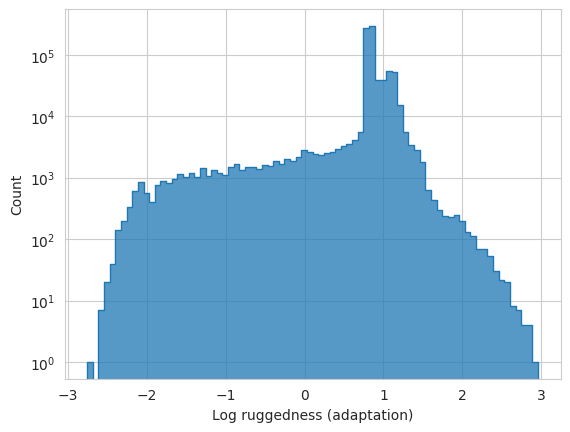

In [6]:
sns.histplot(data[data['sample_name'] == 'RNA_2'], 
             x='Log ruggedness (adaptation)', bins=80, element='step')
plt.yscale('log')


# Motifs

In [7]:
def plot_cluster(interactions, row_colors, n_clusters=6, save_path=None, palette='pastel'):
    g = sns.clustermap(interactions, col_cluster=False, row_colors=row_colors,
                   cbar_kws={'location': 'top', 'label': 'MFE (kcal/mol)'},
                   cmap='mako')
    row_linkage = g.dendrogram_row.linkage
    clusters = fcluster(row_linkage, t=n_clusters, criterion='maxclust')
    x0, _y0, _w, _h = g.cbar_pos
    g.ax_cbar.set_position([x0, 0.85, g.ax_row_dendrogram.get_position().width * 1.3, 0.02])

    if row_colors is None:
        plt.close()
        del g

    lut = dict(zip(sorted(pd.Series(clusters).unique()),
                   sns.color_palette(palette, n_clusters).as_hex()))
    row_colors = pd.Series(clusters).map(lut).to_numpy()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    return row_colors, clusters, n_clusters


filt_adapt = data['adaptation'] > 855
idxs_a_hirugg = data[filt_adapt & (data['Log ruggedness (adaptation)'] > 1.1)].index
idxs_a_lorugg = data[filt_adapt & (data['Log ruggedness (adaptation)'] < 0.4)].index
idxs_a = data[(data['Log sensitivity'] > -0.2) & (data['Log precision'] > 0.5)].index
len(idxs_a)


84

/tmp/ipykernel_3637578/2690833113.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.violinplot(data=d, x='Cluster', y='Log ruggedness (adaptation)',
/tmp/ipykernel_3637578/2690833113.py:68: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  g = sns.violinplot(data=d, x='Cluster', y='Log ruggedness (adaptation)',
/tmp/ipykernel_3637578/2690833113.py:71: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  g = sns.scatterplot(data=d, x='Cluster 0', y='Log ruggedness (adaptation)', hue='Cluster',
/tmp/ipykernel_3637578/2690833113.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.violinplot(data=d, x='Cluster

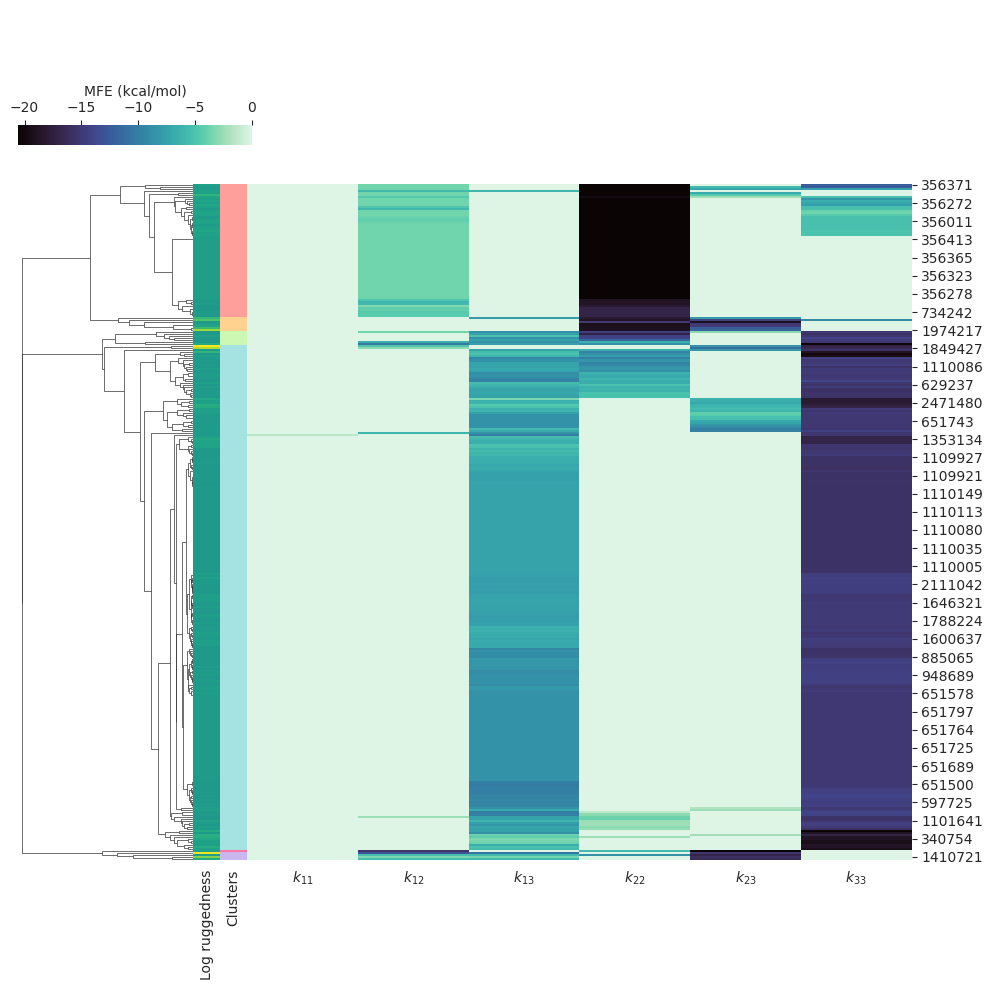

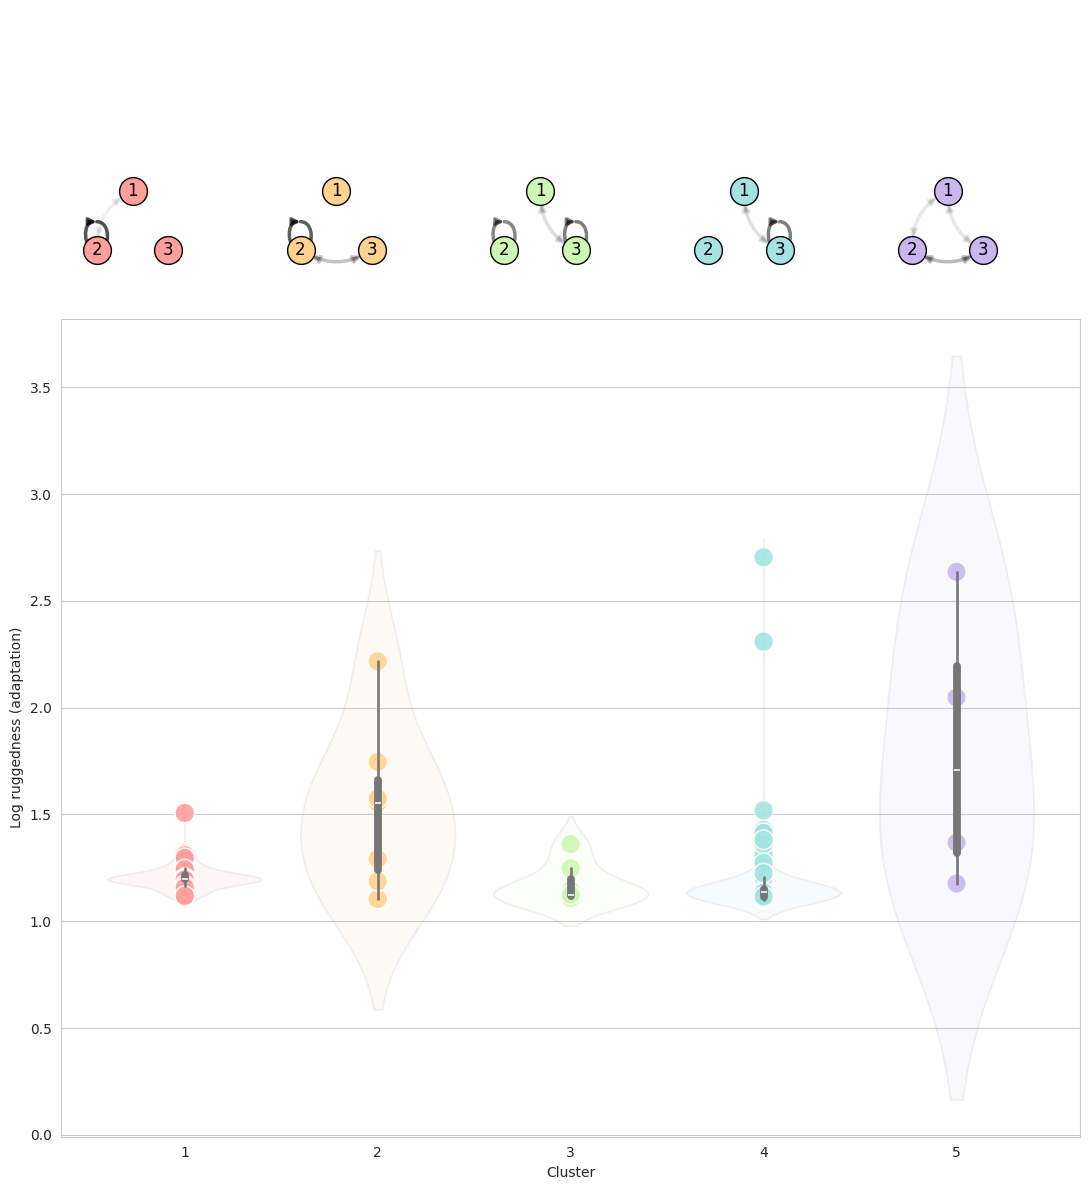

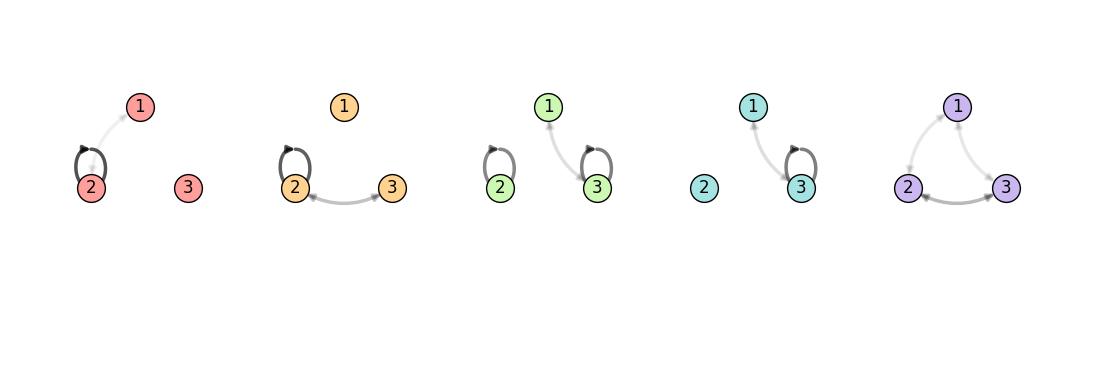

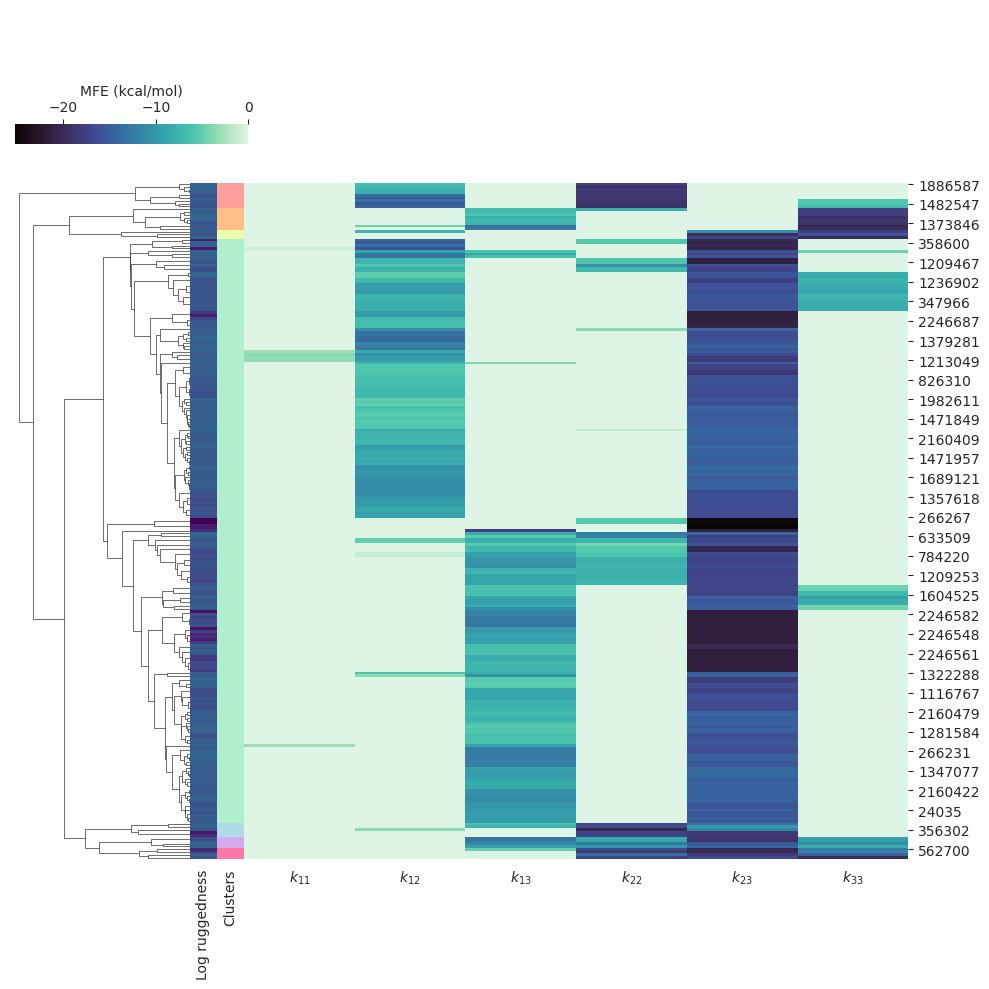

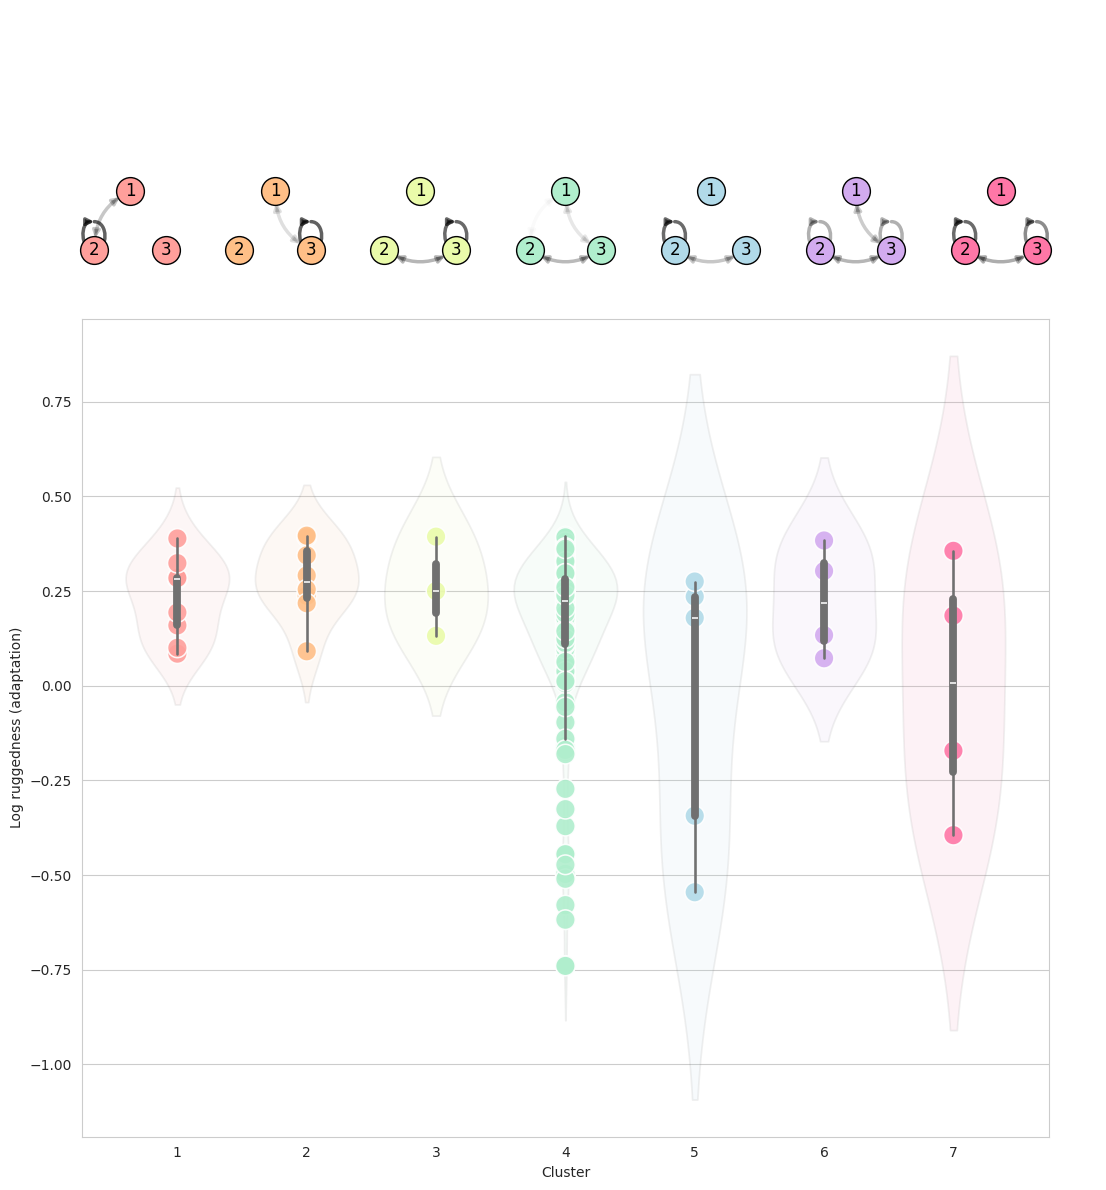

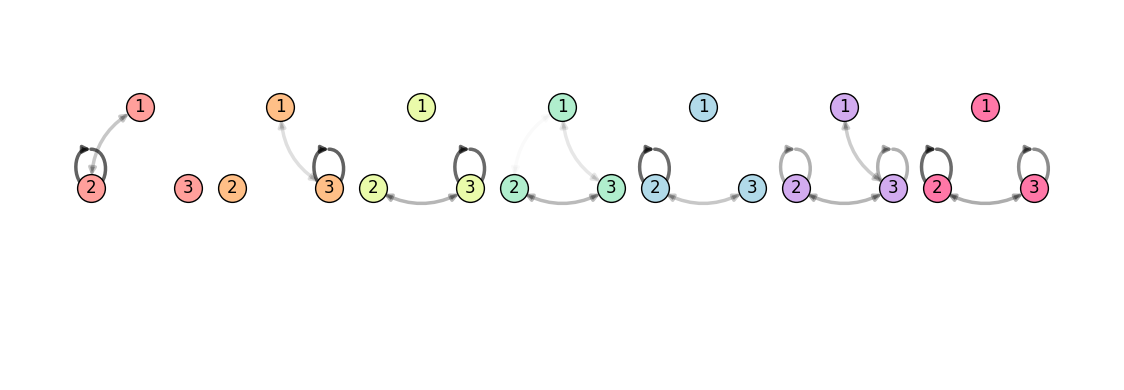

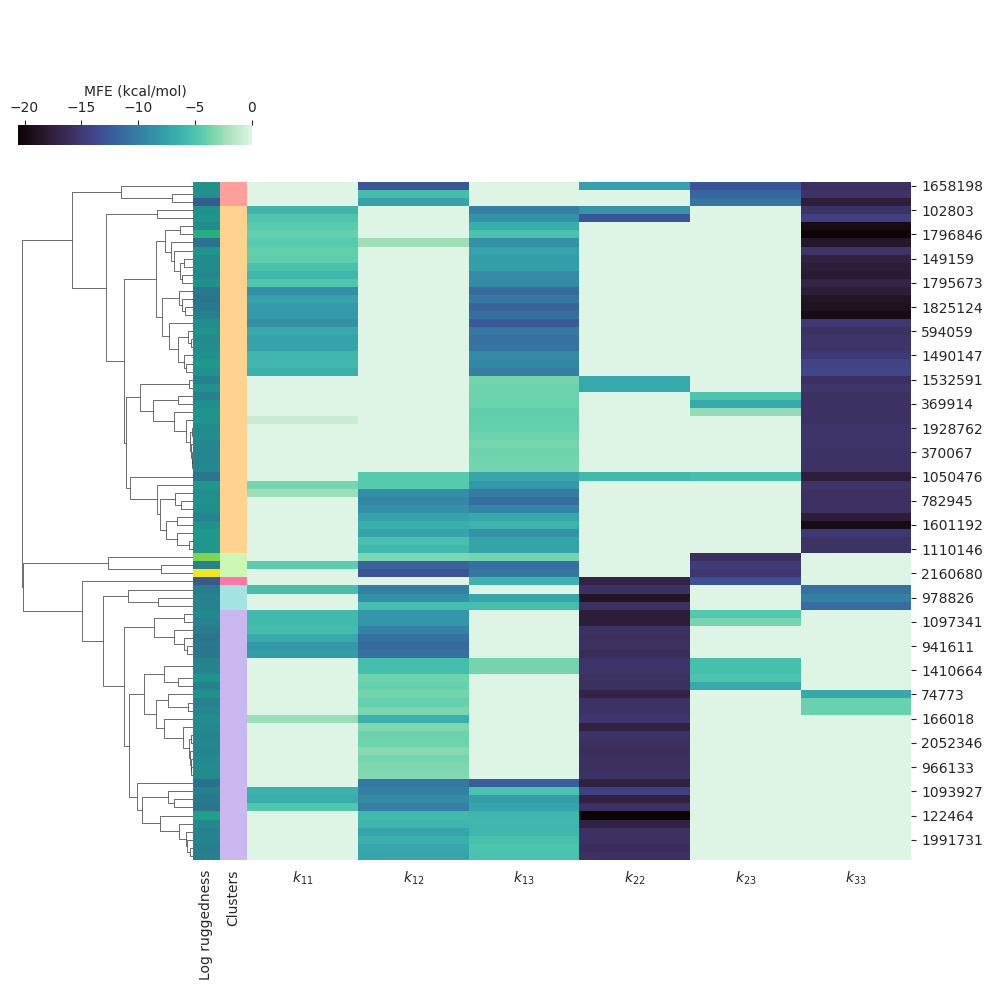

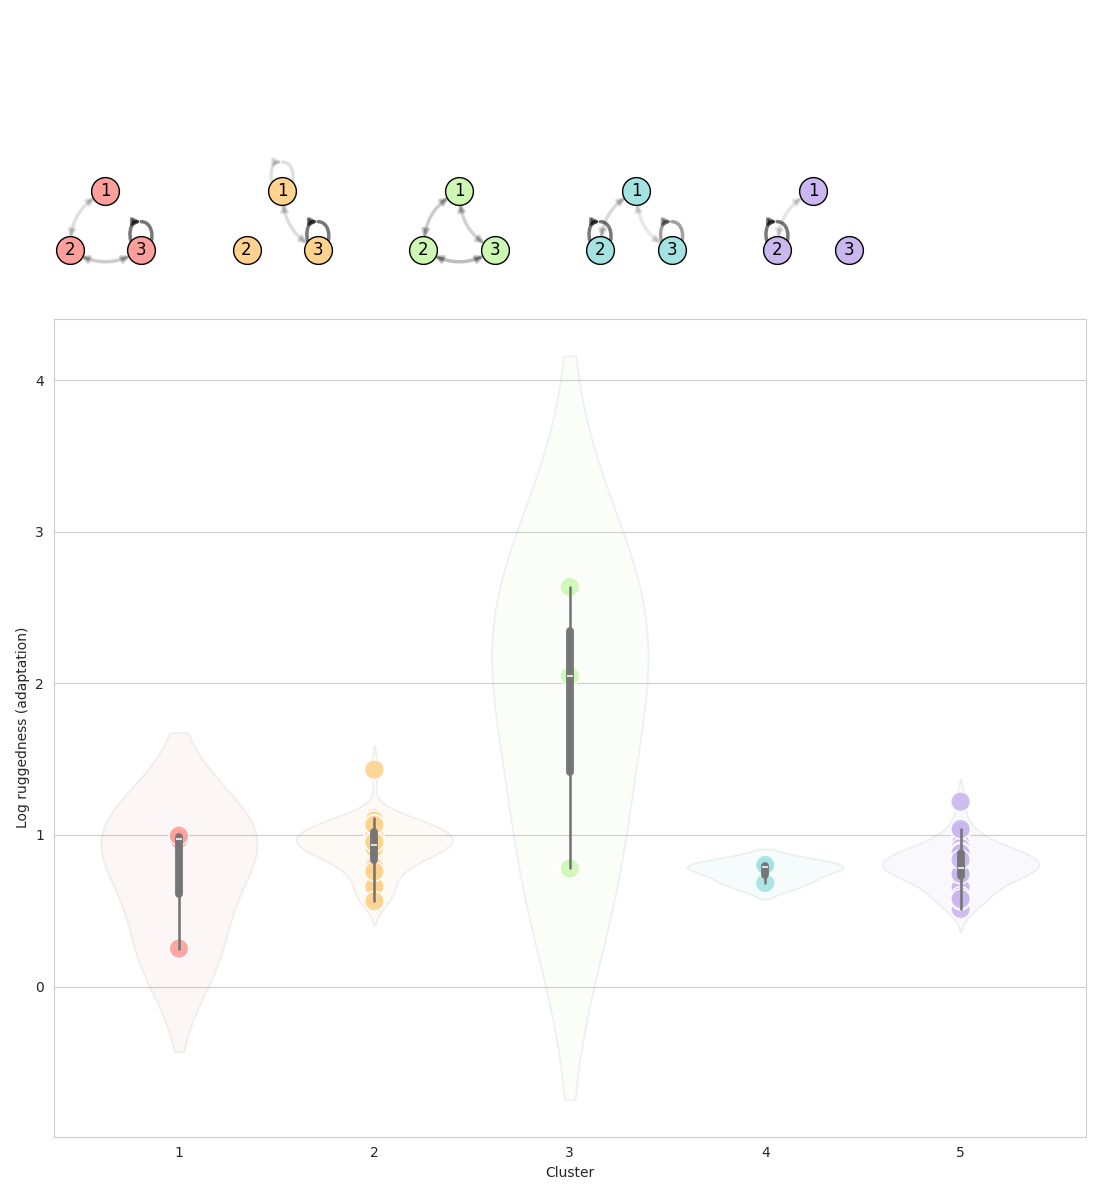

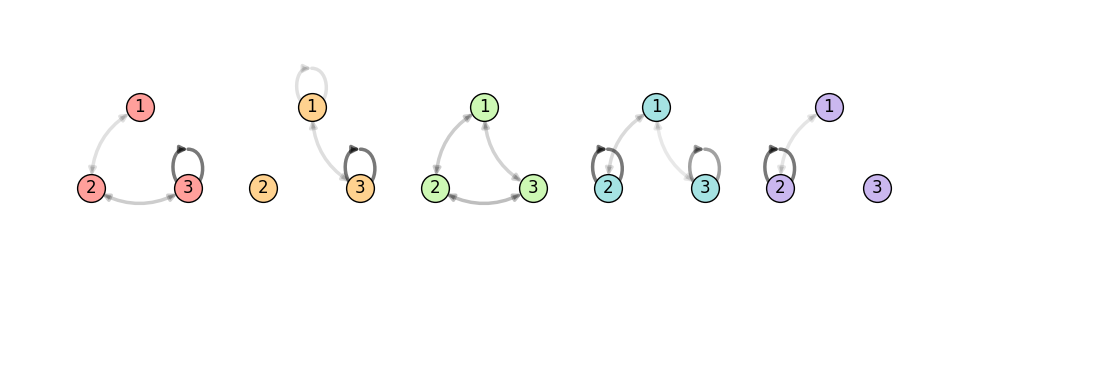

In [ ]:
import matplotlib.colors as mcolors
e_vmin = -30
e_vmax = 0
from common import set_theme
set_theme()

col = 'Log ruggedness (adaptation)'
rugg_min = np.nanmin(data[filt_adapt][np.abs(data[filt_adapt][col]) < np.inf][col])
rugg_max = np.nanmax(data[filt_adapt][np.abs(data[filt_adapt][col]) < np.inf][col])
def norm_val(x):
    if rugg_max != rugg_min:
        return (x - rugg_min) / (rugg_max - rugg_min)
    else:
        return np.zeros_like(x)
    
for idxs, label, n_clusters, pos_multiplier, pos_left in zip(
    [idxs_a_hirugg, idxs_a_lorugg, idxs_a], ['high', 'low', 'adapt_strict'], [6, 7, 6], [1.4, 1.2, 1.2], [-0.2, -0.25, -0.25]):
    
    custom_palette = sns.blend_palette(
        ['#ff9f9b', '#ffb482', '#fffea3', '#c1f6b8', '#a0e7e0', '#b9d3ee', '#d6a4ef', '#ff77a7'], n_colors=n_clusters)
    colors = sns.color_palette(custom_palette, n_clusters).as_hex()

    row_colors = None
    row_colors, clusters, n_clusters = plot_cluster(
        data[x_cols].iloc[idxs], row_colors, n_clusters, palette=custom_palette)
    
    d_row_colors = pd.DataFrame()
    d_row_colors['Log ruggedness'] = data['Log ruggedness (adaptation)'].iloc[idxs].apply(lambda x: norm_val(x)).map(
            lambda x: mcolors.to_hex(sns.color_palette('viridis', as_cmap=True)(x)) if ~np.isnan(x) else '#ffffff')
    d_row_colors['Clusters'] = row_colors
    row_colors, clusters, n_clusters = plot_cluster(
        data[x_cols].iloc[idxs], d_row_colors, n_clusters, palette=custom_palette,
        save_path=os.path.join(top_write_dir, f'motifs_adapt_{label[:2]}rugg_clustermap.png'))

    d = pd.DataFrame()
    d[x_cols + ['adaptation', 'Log ruggedness (adaptation)']] = data[
        x_cols + ['adaptation', 'Log ruggedness (adaptation)']].iloc[idxs]
    d['Cluster'] = clusters
    d = d[d['Cluster'].apply(
        lambda x: np.where(clusters == x, 1, 0).sum() > 2)]

    for plot_opt in ['with scatter', 'without scatter']:
        if plot_opt == "without scatter":
            savename = f'motifs_adapt_{label[:2]}rugg.png'
            fig, ax = plt.subplots(1, 1, figsize=(11, 4))
            pos = np.concatenate([(np.arange(n_clusters) / (n_clusters+1) + pos_left) * pos_multiplier,
                                np.ones(n_clusters) * 0.3]).reshape(2, -1).T
        else:
            savename = f'motifs_adapt_{label[:2]}rugg_scatter.png'
            fig = plt.figure(figsize=(11, 12))
            gs = fig.add_gridspec(2, 1, height_ratios=[1, 3])
            ax = fig.add_subplot(gs[0])
            pos = np.concatenate([(np.arange(n_clusters) / (n_clusters+1) + pos_left) * pos_multiplier,
                                np.ones(n_clusters) * - 0.1]).reshape(2, -1).T

        for i, c in enumerate(sorted(d['Cluster'].unique())):
            interactions_curr = d[d['Cluster'] == c][x_cols].values
            w = np.median(interactions_curr, axis=0)
            create_network_inset(fig, ax,
                                pos=pos[i],
                                width=0.7, height=0.7, 
                                edge_weights=make_nx_weights(w, n_nodes=3, # np.nanmin(data[x_cols]),
                                                            vmin=e_vmin,
                                                            vmax=e_vmax),  # np.nanmax(data[x_cols]),),
                                node_color=colors[c-1], linewidth=2.5)
        ax.set_axis_off()

        if plot_opt == "with scatter":
            ax_bottom = fig.add_subplot(gs[1])
            g = sns.violinplot(data=d, x='Cluster', y='Log ruggedness (adaptation)',
                            ax=ax_bottom, palette=custom_palette, alpha=0.1)
            d['Cluster 0'] = d['Cluster'] - 1
            g = sns.scatterplot(data=d, x='Cluster 0', y='Log ruggedness (adaptation)', hue='Cluster', 
                                ax=ax_bottom, palette=custom_palette,
                                s=200, alpha=0.9, legend=False)
        plt.tight_layout()
        plt.savefig(os.path.join(top_write_dir, savename),
                    dpi=300, bbox_inches='tight')